
# 3. Exploración inicial de datos 

En esta sección se desarrolla una exploración inicial del conjunto de datos de nivel empleado en el estudio. En primer lugar, se examinan las dimensiones del dataset, los tipos de datos y los valores faltantes de las series con el fin de verificar su consistencia y alcance. Posteriormente, se analizan las características estadísticas y distributivas de las variables mediante histogramas y diagramas de caja, lo que permite reconocer tendencias generales, dispersión, asimetrías y posibles valores atípicos antes de avanzar hacia análisis de correlación.




## 3.1. Inspección inicial de datos

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ruta = r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\Niveles_alineados.csv"
df = pd.read_csv(ruta, parse_dates=["Fecha"])

df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")
df = df.sort_values("Fecha").reset_index(drop=True)

df.head()


,Fecha,Calamar,Achi,ElBanco
0,1975-06-17,578.0,565.0,734.0
1,1975-06-18,580.0,564.0,727.0
2,1975-06-19,580.0,562.0,721.0
3,1975-06-20,580.0,557.0,708.0
4,1975-06-21,578.0,541.0,700.0


In [61]:
# Dimensión, tipo de datos, rango temporal

print("Dimensiones del dataset:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

Dimensiones del dataset: (18516, 4)

Tipos de datos:
Fecha      datetime64[ns]
Calamar           float64
Achi              float64
ElBanco           float64
dtype: object


In [62]:
# Rango temporal

print("\nFecha inicial:", df["Fecha"].min()) 
print("Fecha final:", df["Fecha"].max()) 
print("Número de fechas únicas:", df["Fecha"].nunique())


Fecha inicial: 1975-06-17 00:00:00
Fecha final: 2026-02-24 00:00:00
Número de fechas únicas: 18516


In [63]:
# Resumen DataFrame

df.info()
df[["Calamar", "Achi", "ElBanco"]].describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18516 entries, 0 to 18515
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Fecha    18516 non-null  datetime64[ns]
 1   Calamar  18366 non-null  float64       
 2   Achi     14949 non-null  float64       
 3   ElBanco  18094 non-null  float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 578.8 KB


,Calamar,Achi,ElBanco
count,18366.00,14949.00,18094.00
mean,548.56,461.38,636.94
std,168.43,141.81,139.63
min,112.00,50.00,241.00
25%,438.00,366.00,537.00
50%,554.00,463.00,639.00
75%,671.00,554.00,741.35
max,950.00,829.00,957.00


In [64]:
# Datos faltantes

df.isnull().sum()

Fecha         0
Calamar     150
Achi       3567
ElBanco     422
dtype: int64

## 3.2. Histogramas de las series

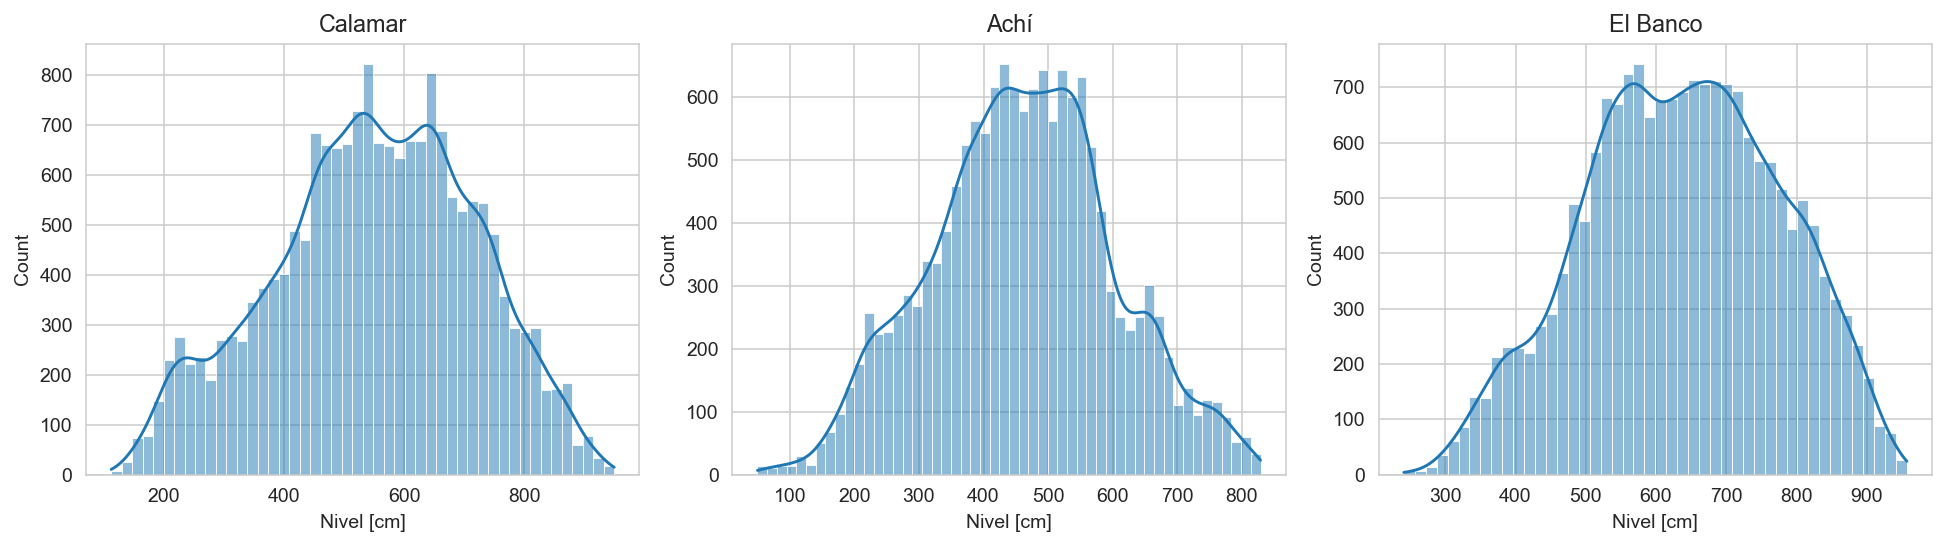

In [ ]:

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=140)

sns.histplot(df["Calamar"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Calamar")

sns.histplot(df["Achi"].dropna(), kde=True, ax=axes[1])
axes[1].set_title("Achí")

sns.histplot(df["ElBanco"].dropna(), kde=True, ax=axes[2])
axes[2].set_title("El Banco")

for ax in axes:
    ax.set_xlabel("Nivel [cm]")

plt.tight_layout()
plt.show()

## 3.3. Box Plots de las series de nivel

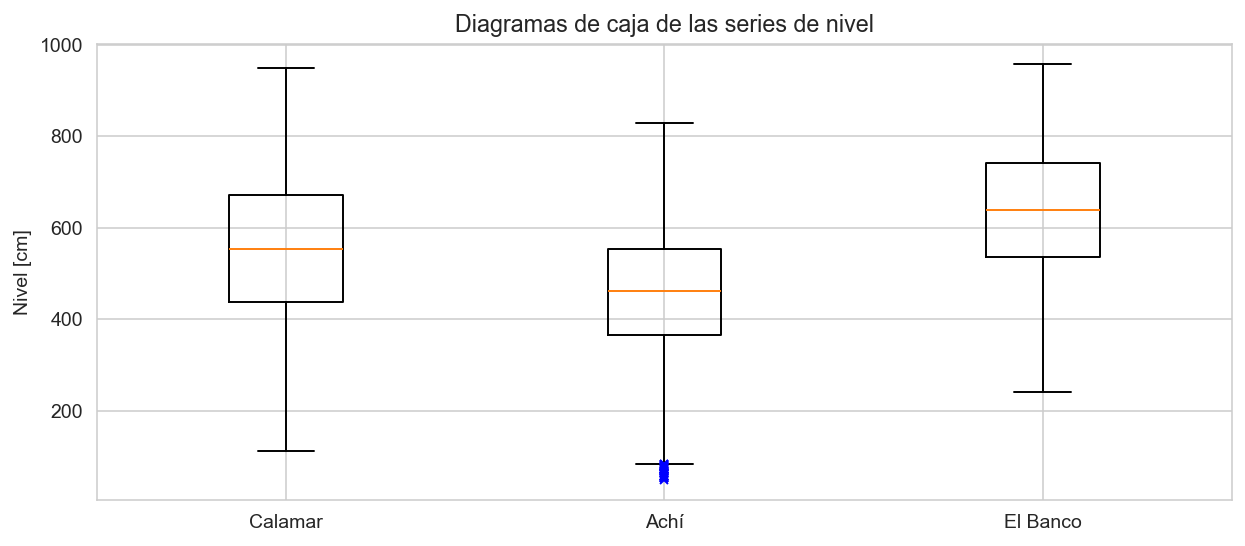

In [ ]:

plt.figure(figsize=(9, 4), dpi=140)

plt.boxplot(
    [
        df["Calamar"].dropna(),
        df["Achi"].dropna(),
        df["ElBanco"].dropna()
    ],
    tick_labels=["Calamar", "Achí", "El Banco"],
    flierprops=dict(
        marker='x',
        markeredgecolor='blue',
        markersize=4,
        linestyle='none'
    )
)

plt.title("Diagramas de caja de las series de nivel")
plt.ylabel("Nivel [cm]")
plt.tight_layout()
plt.show()